In [1]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split

from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
SEED = 42
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_CLASSES = 3

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

df = pd.read_csv('dataset_filtered.csv')
df['use_no_bg'] = df['use_no_bg'].astype(bool)

label_to_idx = {l:i for i,l in enumerate(sorted(df['label'].unique()))}
idx_to_label = {l:i for l, i in label_to_idx.items()}
class_names = sorted(label_to_idx.keys())

cuda


In [3]:
print(f"Total sampel: {len(df)}")
print(f"Label mapping: {label_to_idx}")

Total sampel: 26197
Label mapping: {'Electronic': 0, 'Organic': 1, 'Recyclable': 2}


## Pipeline

In [4]:
class MixedDataset(Dataset):
    """
    Dataset bakal memilih acak gambar yang di-augmentasi berikut:
    - Gambar asli + augmentasi (sedikit lebih agresif)
    - Gambar no-background + augmentasi (jika use_no_bg=True)
    """
    def __init__(self, dataframe, heavy_transform, light_transform):
        self.df = dataframe.reset_index(drop=True)
        self.heavy = heavy_transform
        self.light = light_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = label_to_idx[row['label']]

        if row['use_no_bg'] and random.random() < 0.5:
            img = Image.open(row['final_path']).convert('RGB')
            img = self.light(img)
        else:
            img = Image.open(row['file_path']).convert('RGB')
            img = self.heavy(img)
        return img, label

In [5]:
class EvalDataset(Dataset):
    """
    Dataset untuk validasi (nanti di split)
    """
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['file_path']).convert('RGB')
        img = self.transform(img)
        return img, label_to_idx[row['label']]

In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    pbar = tqdm(loader, desc="[Train]")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return running_loss / len(loader)

In [7]:
def validasi_epoch(model, loader, criterion, device):
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="[Val]"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return val_loss / len(loader), acc, all_preds, all_labels

In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, device, class_names):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{num_epochs}")

        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, preds, labels = validasi_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        scheduler.step()

    return history, preds, labels

In [9]:
def plot_hasil(history, all_preds, all_labels, class_names):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss curves
    axes[0].plot(history['train_loss'], marker='o', label='Train Loss')
    axes[0].plot(history['val_loss'], marker='o', label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curves')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy curve
    axes[1].plot(history['val_acc'], marker='o', color='green', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Validation Accuracy')
    axes[1].grid(True, alpha=0.3)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[2])
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('True')
    axes[2].set_title('Confusion Matrix')

    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

In [10]:
def model(model_name='resnet50', num_classes=3):
    """
    Factory model untuk sekali inisiasi

    :param model_name: Nama model yang akan digunakan (pilih antara resnet50, efficientnet_b3, convnext_tiny, swin_t). Default: resnet50
    :param num_classes: Jumlah label/class
    :return: model
    """

    match model_name:
        case 'resnet50':
            model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        case 'efficientnet_b3':
            model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        case 'convnext_tiny':
            model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
            model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
        case 'swin_t':
            model = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)
            model.head = nn.Linear(model.head.in_features, num_classes)
    return model

In [11]:
# buat heavy augment
htrain = transforms.Compose([
    transforms.Resize((256)),
    transforms.RandomResizedCrop(224, scale=(0.08,1.0), ratio=(0.75,1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

# light augment
ltrain = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.3,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

# eval
etransform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [12]:
full_dataset = MixedDataset(df, htrain, ltrain)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])


df_val = df.iloc[val_dataset.indices]
val_eval_dataset = EvalDataset(df_val, etransform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,drop_last=True)
val_loader = DataLoader(val_eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [13]:
train_labels = [label_to_idx[df.iloc[i]['label']] for i in train_dataset.indices]
class_counts = np.bincount(train_labels)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)
class_weights = class_weights / class_weights.sum() * len(class_counts)
print(f"Class weights: {class_weights.cpu().numpy()}")

Class weights: [1.759891   0.54723155 0.69287753]


In [14]:
# class FocalLoss(nn.Module):
#     def __init__(self, alpha=None, gamma=2.0):
#         super().__init__()
#         self.alpha = alpha
#         self.gamma = gamma
#
#     def forward(self, inputs, targets):
#         ce_loss = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')
#         ce = ce_loss(inputs, targets)
#         pt = torch.exp(-ce)
#         focal_loss = ((1 - pt) ** self.gamma * ce).mean()
#         return focal_loss

In [15]:
mixup_fn = Mixup(
    mixup_alpha=1.0,
    cutmix_alpha=1.0,
    prob=0.5,
    switch_prob=0.5,
    mode='batch',
    num_classes=NUM_CLASSES
)

## Resnet50

In [16]:
# model_resnet = model('resnet50', num_classes=3).to(device)

In [17]:
# criterion = nn.CrossEntropyLoss(weight=class_weights)
# criterion_soft = SoftTargetCrossEntropy()
# optimizer = optim.AdamW(model_resnet.parameters(), lr=LEARNING_RATE)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [18]:
# train_losses = []
# val_losses = []
# val_accuracies = []
#
# for epoch in range(EPOCHS):
#     # Training
#     model_resnet.train()
#     running_loss = 0.0
#     pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
#     for imgs, labels in pbar:
#         imgs, labels = imgs.to(device), labels.to(device)
#         imgs, labels_mixed = mixup_fn(imgs, labels)
#
#         optimizer.zero_grad()
#         outputs = model_resnet(imgs)
#
#         if labels_mixed.dim() == 1:
#             loss = criterion(outputs, labels_mixed)
#         else:
#             loss = criterion_soft(outputs, labels_mixed)
#
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#         pbar.set_postfix(loss=f"{loss.item():.4f}")
#
#     train_losses.append(running_loss / len(train_loader))
#
#     # Validasi
#     model_resnet.eval()
#     val_loss = 0.0
#     all_preds, all_labels = [], []
#     with torch.no_grad():
#         for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
#             imgs, labels = imgs.to(device), labels.to(device)
#             outputs = model_resnet(imgs)
#             loss = criterion(outputs, labels)
#             val_loss += loss.item()
#             _, preds = torch.max(outputs, 1)
#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())
#
#     val_losses.append(val_loss / len(val_loader))
#     acc = np.mean(np.array(all_preds) == np.array(all_labels))
#     val_accuracies.append(acc)
#     print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}, Val Acc={acc:.4f}")
#     scheduler.step()

In [19]:
# history = {'train_loss': train_losses, 'val_loss': val_losses, 'val_acc': val_accuracies}
# plot_hasil(history, all_preds, all_labels, class_names)

## Efficientnet_B3

In [20]:
# model_b3 = model('efficientnet_b3', num_classes=3).to(device)

In [21]:
# criterion = nn.CrossEntropyLoss(weight=class_weights)
# criterion_soft = SoftTargetCrossEntropy()
# optimizer = optim.AdamW(model_b3.parameters(), lr=LEARNING_RATE)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [22]:
# train_losses = []
# val_losses = []
# val_accuracies = []
#
# for epoch in range(EPOCHS):
#     # Training
#     model_b3.train()
#     running_loss = 0.0
#     pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
#     for imgs, labels in pbar:
#         imgs, labels = imgs.to(device), labels.to(device)
#         imgs, labels_mixed = mixup_fn(imgs, labels)
#
#         optimizer.zero_grad()
#         outputs = model_b3(imgs)
#
#         if labels_mixed.dim() == 1:
#             loss = criterion(outputs, labels_mixed)
#         else:
#             loss = criterion_soft(outputs, labels_mixed)
#
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#         pbar.set_postfix(loss=f"{loss.item():.4f}")
#
#     train_losses.append(running_loss / len(train_loader))
#
#     # Validasi
#     model_b3.eval()
#     val_loss = 0.0
#     all_preds, all_labels = [], []
#     with torch.no_grad():
#         for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
#             imgs, labels = imgs.to(device), labels.to(device)
#             outputs = model_b3(imgs)
#             loss = criterion(outputs, labels)
#             val_loss += loss.item()
#             _, preds = torch.max(outputs, 1)
#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())
#
#     val_losses.append(val_loss / len(val_loader))
#     acc = np.mean(np.array(all_preds) == np.array(all_labels))
#     val_accuracies.append(acc)
#     print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}, Val Acc={acc:.4f}")
#     scheduler.step()

In [23]:
# history = {'train_loss': train_losses, 'val_loss': val_losses, 'val_acc': val_accuracies}
# plot_hasil(history, all_preds, all_labels, class_names)

In [24]:
# history = {'train_loss': train_losses, 'val_loss': val_losses, 'val_acc': val_accuracies}
# plot_hasil(history, all_preds, all_labels, class_names)

## ConvNext

In [25]:
model_convn = model('convnext_tiny', num_classes=3).to(device)

In [26]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
criterion_soft = SoftTargetCrossEntropy()
optimizer = optim.AdamW(model_convn.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [27]:
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    # Training
    model_convn.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        imgs, labels_mixed = mixup_fn(imgs, labels)

        optimizer.zero_grad()
        outputs = model_convn(imgs)

        if labels_mixed.dim() == 1:
            loss = criterion(outputs, labels_mixed)
        else:
            loss = criterion_soft(outputs, labels_mixed)

        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_losses.append(running_loss / len(train_loader))

    # Validasi
    model_convn.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model_convn(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_losses.append(val_loss / len(val_loader))
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    val_accuracies.append(acc)
    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}, Val Acc={acc:.4f}")
    scheduler.step()

Epoch 1/10 [Val]: 100%|██████████| 164/164 [00:40<00:00,  4.07it/s]


Epoch 1: Train Loss=0.5745, Val Loss=0.1926, Val Acc=0.9456


Epoch 2/10 [Val]: 100%|██████████| 164/164 [00:35<00:00,  4.64it/s]


Epoch 2: Train Loss=0.5347, Val Loss=0.1883, Val Acc=0.9448


Epoch 3/10 [Val]: 100%|██████████| 164/164 [00:41<00:00,  3.94it/s]


...

Epoch 8: Train Loss=0.4785, Val Loss=0.1391, Val Acc=0.9685


Epoch 9/10 [Val]: 100%|██████████| 164/164 [00:35<00:00,  4.60it/s]


Epoch 9: Train Loss=0.4748, Val Loss=0.1417, Val Acc=0.9670


Epoch 10/10 [Val]: 100%|██████████| 164/164 [00:35<00:00,  4.63it/s]

Epoch 10: Train Loss=0.4595, Val Loss=0.1411, Val Acc=0.9674


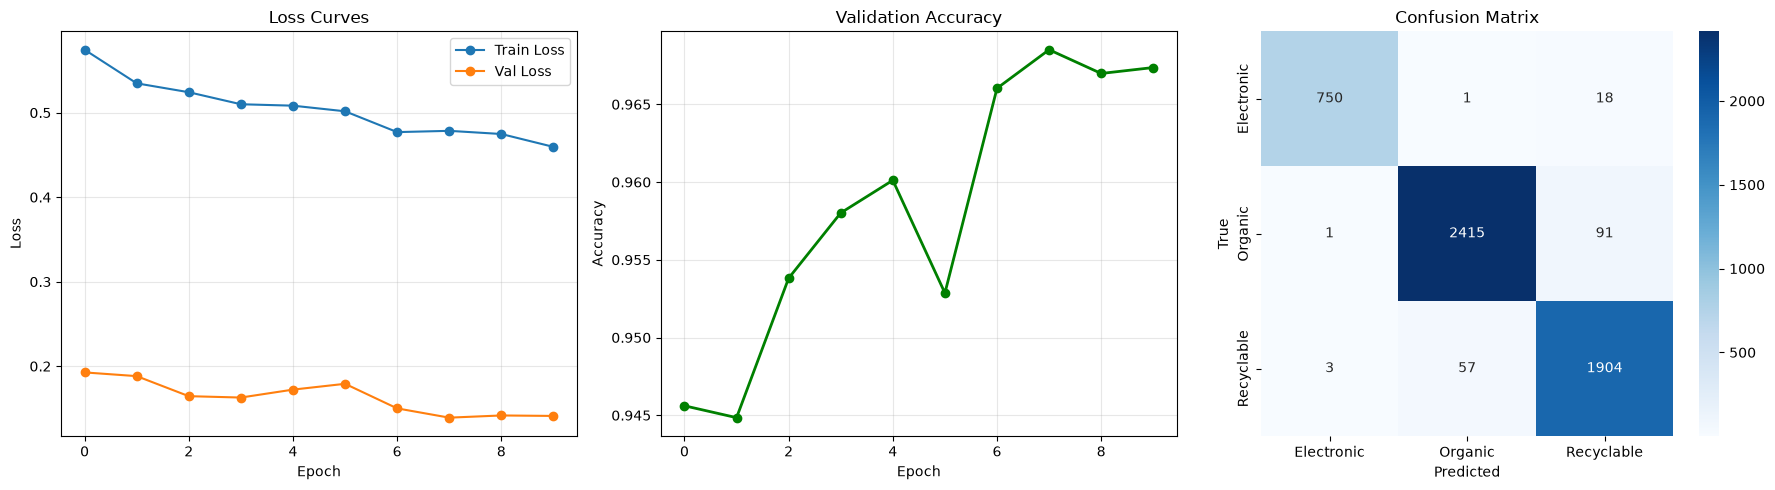


Classification Report:
              precision    recall  f1-score   support

  Electronic       0.99      0.98      0.98       769
     Organic       0.98      0.96      0.97      2507
  Recyclable       0.95      0.97      0.96      1964

    accuracy                           0.97      5240
   macro avg       0.97      0.97      0.97      5240
weighted avg       0.97      0.97      0.97      5240



In [28]:
history = {'train_loss': train_losses, 'val_loss': val_losses, 'val_acc': val_accuracies}
plot_hasil(history, all_preds, all_labels, class_names)

In [29]:
torch.save(model_convn.state_dict(), 'trained_model/convnext2.pth')

## Swin T

In [30]:
model_swin = model('swin_t', num_classes=3).to(device)

In [31]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
criterion_soft = SoftTargetCrossEntropy()
optimizer = optim.AdamW(model_swin.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [32]:
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    # Training
    model_swin.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        imgs, labels_mixed = mixup_fn(imgs, labels)

        optimizer.zero_grad()
        outputs = model_swin(imgs)

        if labels_mixed.dim() == 1:
            loss = criterion(outputs, labels_mixed)
        else:
            loss = criterion_soft(outputs, labels_mixed)

        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_losses.append(running_loss / len(train_loader))

    # Validasi
    model_swin.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model_swin(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_losses.append(val_loss / len(val_loader))
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    val_accuracies.append(acc)
    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}, Val Acc={acc:.4f}")
    scheduler.step()

Epoch 1/10 [Val]: 100%|██████████| 164/164 [00:37<00:00,  4.33it/s]


Epoch 1: Train Loss=0.6117, Val Loss=0.1993, Val Acc=0.9408


Epoch 2/10 [Val]: 100%|██████████| 164/164 [00:37<00:00,  4.34it/s]


Epoch 2: Train Loss=0.5594, Val Loss=0.2451, Val Acc=0.9361


Epoch 3/10 [Val]: 100%|██████████| 164/164 [00:42<00:00,  3.84it/s]


...

Epoch 8: Train Loss=0.4945, Val Loss=0.1475, Val Acc=0.9622


Epoch 9/10 [Val]: 100%|██████████| 164/164 [00:42<00:00,  3.86it/s]


Epoch 9: Train Loss=0.4827, Val Loss=0.1391, Val Acc=0.9639


Epoch 10/10 [Val]: 100%|██████████| 164/164 [00:42<00:00,  3.84it/s]

Epoch 10: Train Loss=0.4818, Val Loss=0.1401, Val Acc=0.9637


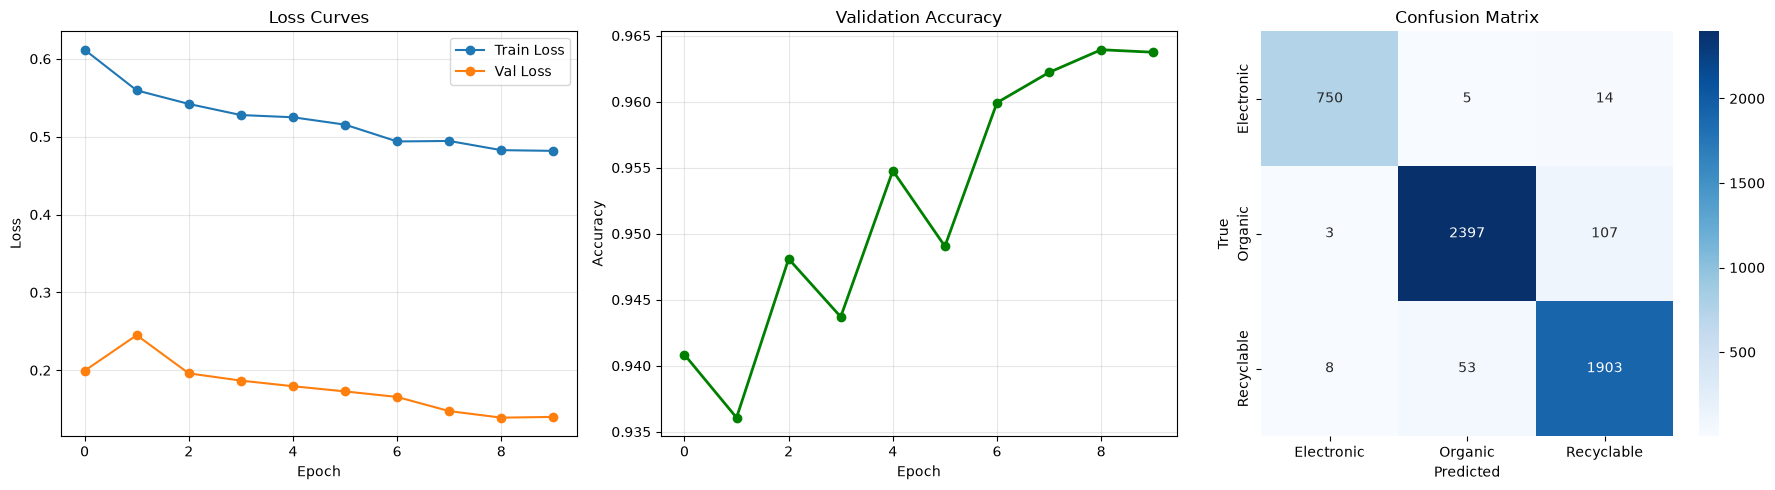


Classification Report:
              precision    recall  f1-score   support

  Electronic       0.99      0.98      0.98       769
     Organic       0.98      0.96      0.97      2507
  Recyclable       0.94      0.97      0.95      1964

    accuracy                           0.96      5240
   macro avg       0.97      0.97      0.97      5240
weighted avg       0.96      0.96      0.96      5240



In [33]:
history = {'train_loss': train_losses, 'val_loss': val_losses, 'val_acc': val_accuracies}
plot_hasil(history, all_preds, all_labels, class_names)

In [34]:
model_swin.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (

In [35]:
torch.save(model_swin.state_dict(), 'swin_t2.pth')

## Testing

In [36]:
df_sub = pd.read_csv('submission.csv')
ids = df_sub['id'].values

df_sub.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         1458 non-null   int64  
 1   predicted  0 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 22.9 KB


In [37]:
class TestDataset(Dataset):
    def __init__(self, ids, test_dir, transform=None):
        self.ids = ids
        self.test_dir = Path(test_dir)
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_path = self.test_dir / f"{self.ids[idx]}.jpg"
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

In [38]:
test_dataset = TestDataset(ids, 'test', etransform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [39]:
# Salah mapping
# Model kita: 0=Electronic, 1=Organic, 2=Recyclable
# Ketentuan lomba: 0=Recyclable, 1=Electronic, 2=Organic
model_to_sub = {0: 1, 1: 2, 2: 0}

predicted_labels = []
with torch.no_grad():
    for imgs in tqdm(test_loader, desc="Inference Swin‑T"):
        imgs = imgs.to(device)
        outputs = model_swin(imgs)
        _, preds = torch.max(outputs, 1)
        predicted_labels.extend([model_to_sub[int(p)] for p in preds.cpu().numpy()])

Inference Swin‑T: 100%|██████████| 46/46 [00:13<00:00,  3.43it/s]


In [40]:
type(predicted_labels[4])

int

In [41]:
# submission_df = pd.DataFrame({'id': ids, 'predicted': predicted_labels})
# submission_df.to_csv('submission_swin.csv', index=False)

In [42]:
df_sub = pd.read_csv('submission_swin.csv')
df_sub.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         1458 non-null   int64
 1   predicted  1458 non-null   int64
dtypes: int64(2)
memory usage: 22.9 KB


In [43]:
df_sub.head(10)

,id,predicted
0,1,2
1,2,2
2,3,2
3,4,1
4,5,0
5,6,0
6,7,2
7,8,0
8,9,1
9,10,0
